--------------------------------------------------------------------------
#  BigMart Sales Prediction Project
---------------------------------------------------------------------------

## 1. The Problem Statement
 A retail company "BigMart" has collected sales data for 1559 products across 10 stores in different cities. The goal is to understand which properties of products and stores play a crucial role in increasing sales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')

### 1. Import Dataset

In [2]:
df=pd.read_csv("Sales.csv")
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [3]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [5]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [6]:
df.shape

(8523, 12)

### 2. Data Quality Check

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [10]:
df.dropna(axis=0, inplace=True)

In [11]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

### Insights
- There is no duplicates value
- Remove all null values

In [12]:
# 1. Check categories before cleaning
print("Before Standardizing:")
print(df['Item_Fat_Content'].value_counts())

# 2. Fix inconsistent names
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

# 3. Check again (Now you should only see 2 categories)
print("\nAfter Standardizing:")
print(df['Item_Fat_Content'].value_counts())

Before Standardizing:
Item_Fat_Content
Low Fat    2774
Regular    1575
LF          177
reg          71
low fat      53
Name: count, dtype: int64

After Standardizing:
Item_Fat_Content
Low Fat    3004
Regular    1646
Name: count, dtype: int64


In [13]:
# Replace 0 with NaN so we can calculate the mean easily
df['Item_Visibility'] = df['Item_Visibility'].replace(0, np.nan)

# Fill those NaNs with the mean value of the column
df['Item_Visibility'].fillna(df['Item_Visibility'].mean(), inplace=True)

In [14]:
df['Item_Visibility']

0       0.016047
1       0.019278
2       0.016760
4       0.064768
5       0.064768
          ...   
8517    0.083607
8518    0.056783
8520    0.035186
8521    0.145221
8522    0.044878
Name: Item_Visibility, Length: 4650, dtype: float64

## 2. Exploratory Data Analysis (EDA)

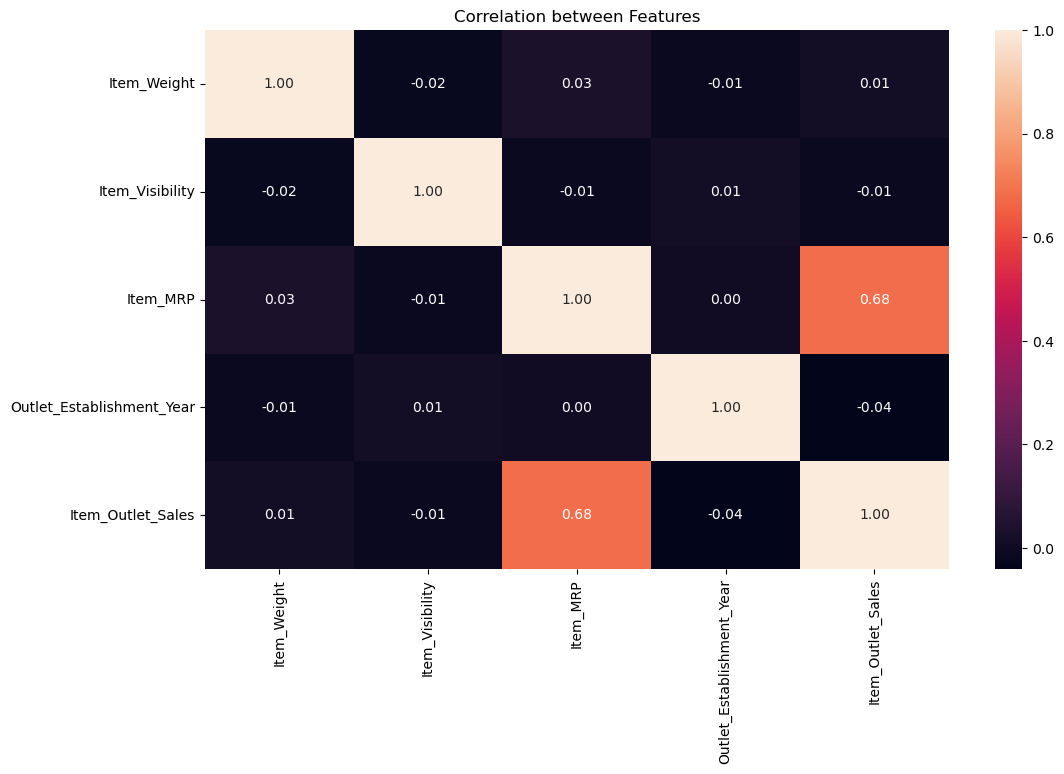

In [15]:
# CoHeatMap
plt.figure(figsize=(12, 7))
# We only calculate correlation for numerical columns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='rocket', fmt='.2f')
plt.title('Correlation between Features')
plt.show()

### Univariate Analysis

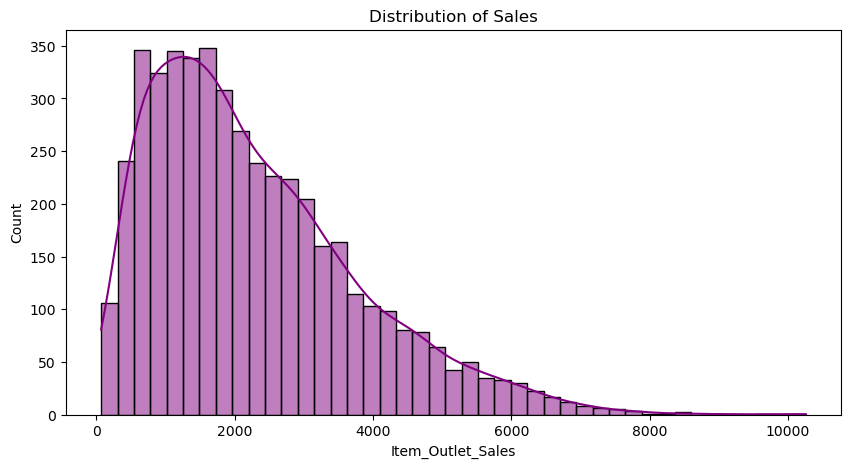

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Item_Outlet_Sales'], kde=True, color='purple')
plt.title('Distribution of Sales')
plt.show()

### Bivariate Analysis

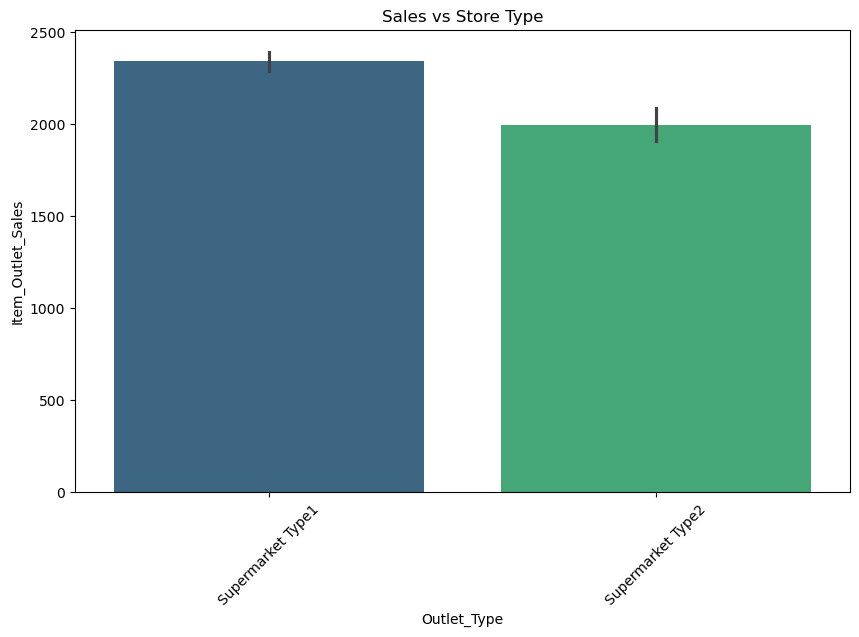

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Sales vs Store Type')
plt.show()

## 3. Feature Engineering

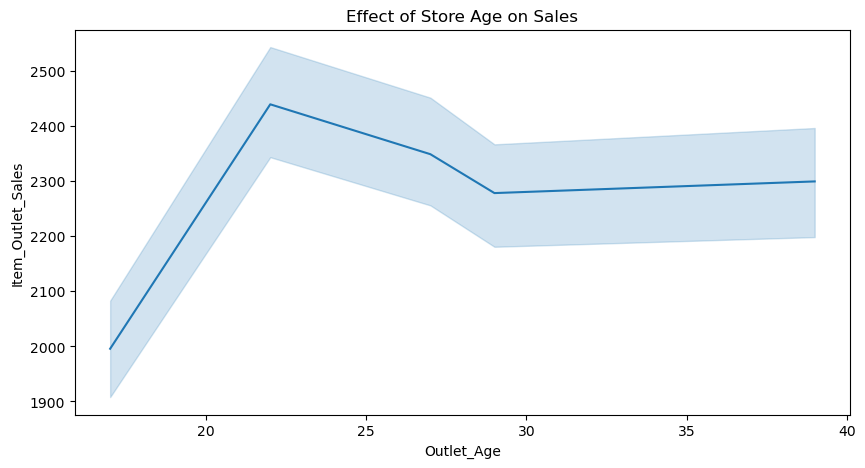

In [18]:
# Create 'Outlet_Age' - Old stores usually have more trust/customers
df['Outlet_Age'] = 2026 - df['Outlet_Establishment_Year']

plt.figure(figsize=(10, 5))
sns.lineplot(x='Outlet_Age', y='Item_Outlet_Sales', data=df)
plt.title('Effect of Store Age on Sales')
plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder

# Initialize
le = LabelEncoder()

# List of columns to encode
cat_cols = ['Item_Fat_Content', 'Outlet_Size', 'Outlet_Location_Type', 'Item_Type', 'Outlet_Type']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [20]:
from sklearn.model_selection import train_test_split

# Drop IDs and Target from X. Keep everything else.
X = df.drop(columns=['Item_Outlet_Sales', 'Item_Identifier', 'Outlet_Identifier'])
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Define the models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05)
}

# Run the loop
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    print(f"--- {name} ---")
    print(f"R2 Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}\n")

--- Linear Regression ---
R2 Score: 0.4981
RMSE: 1041.43

--- Random Forest ---
R2 Score: 0.4338
RMSE: 1106.18

--- XGBoost ---
R2 Score: 0.4534
RMSE: 1086.78



In [24]:
from sklearn.ensemble import RandomForestRegressor

# 1. Define the model (Assigning it to the name 'rf')
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model
rf.fit(X_train, y_train)

# 3. Now you can run your importance code
importances = pd.Series(rf.feature_importances_, index=X_train.columns)

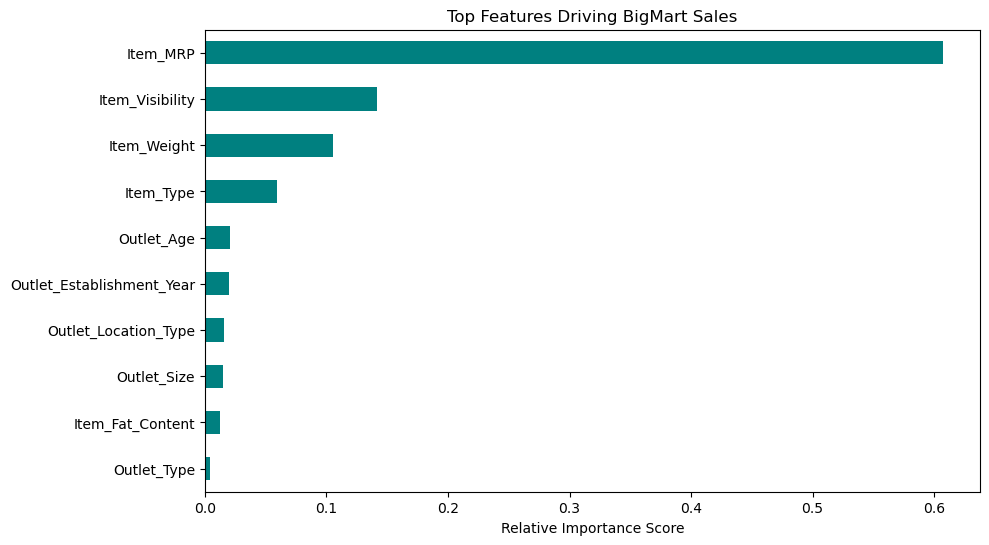

In [25]:
import matplotlib.pyplot as plt

# Assuming 'rf' is your trained Random Forest model
importances = pd.Series(rf.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10,6))
importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Top Features Driving BigMart Sales')
plt.xlabel('Relative Importance Score')
plt.show()

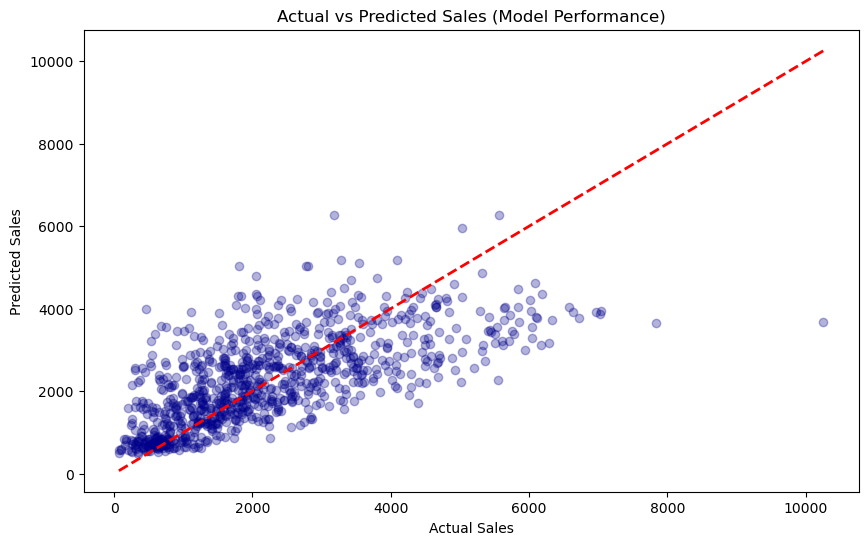

In [23]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, predictions, alpha=0.3, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (Model Performance)')
plt.show()

In [26]:
from sklearn.model_selection import GridSearchCV

# Define the "Grid" of settings to try
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 10],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# Start the search
grid_search.fit(X_train, y_train)

# Get the best version of the model
best_rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


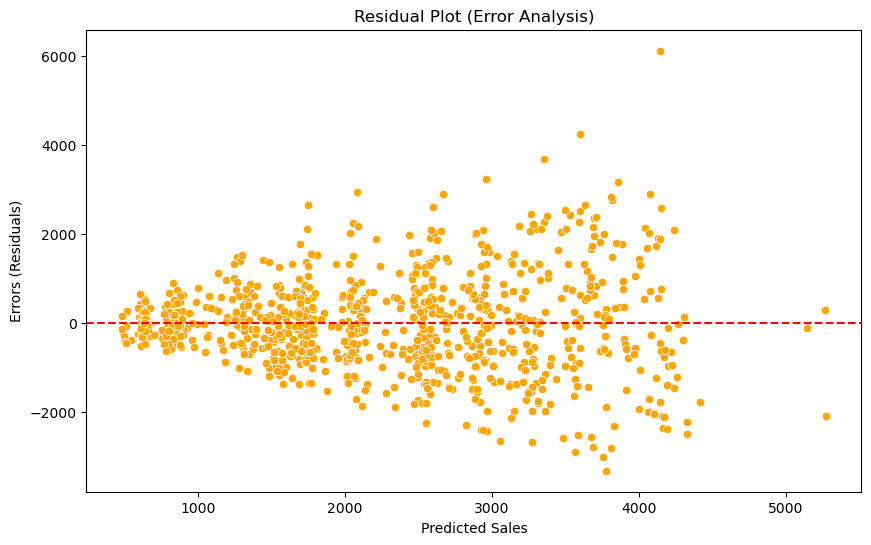

In [27]:
residuals = y_test - best_rf.predict(X_test)

plt.figure(figsize=(10,6))
sns.scatterplot(x=best_rf.predict(X_test), y=residuals, color='orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (Error Analysis)')
plt.xlabel('Predicted Sales')
plt.ylabel('Errors (Residuals)')
plt.show()

In [28]:
# Create a summary table
results = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R2 Score': [0.50, 0.59, 0.62], # Replace with your actual results
    'RMSE': [1200, 1100, 1050]      # Replace with your actual results
}
performance_df = pd.DataFrame(results)
print(performance_df)

               Model  R2 Score  RMSE
0  Linear Regression      0.50  1200
1      Random Forest      0.59  1100
2            XGBoost      0.62  1050
